# 04 - Candidate hubs and distance matrix

Selects the candidate drone hubs from the medical-infrastructure layer and computes the
Haversine air distance from every demand cell to every candidate hub.

**Output:** 59 candidate hubs (53 hospitals, 5 seasonal health centres, 1 ambulance
station) and the 556 x 59 distance matrix used by both optimization models.

In [ ]:
# If needed:
# %pip install -U pandas numpy geopandas folium plotly pyarrow shapely

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import plotly.express as px
from branca.element import Element

PROJECT_ROOT=Path("hajj_drone_project")
PROCESSED_DIR=PROJECT_ROOT/"data"/"processed"
MODEL_DIR=PROJECT_ROOT/"data"/"model"
MAP_DIR=PROJECT_ROOT/"outputs"/"maps"
REPORT_DIR=PROJECT_ROOT/"outputs"/"reports"

for p in [PROCESSED_DIR,MODEL_DIR,MAP_DIR,REPORT_DIR]:
    p.mkdir(parents=True,exist_ok=True)

BASELINE_GRID_M=500
DRONE_RANGE_SCENARIOS_KM=[2.5,5.0,7.5,10.0]

## 1. Load validated medical infrastructure and baseline demand points

In [ ]:
facility_files=[
    PROCESSED_DIR/"hajj_medical_locations_zoned_v1.gpkg",
    PROCESSED_DIR/"hajj_medical_locations_zoned_v1.parquet"
]
demand_files=[
    PROCESSED_DIR/f"hajj_demand_locations_{BASELINE_GRID_M}m_v1.gpkg",
    PROCESSED_DIR/f"hajj_demand_locations_{BASELINE_GRID_M}m_v1.parquet"
]

facility_file=next((p for p in facility_files if p.exists()),None)
demand_file=next((p for p in demand_files if p.exists()),None)

if facility_file is None:
    raise FileNotFoundError("Run notebook 02 first. Zoned medical infrastructure not found.")
if demand_file is None:
    raise FileNotFoundError("Run notebook 03 first. 500 m demand dataset not found.")

facilities=(gpd.read_parquet(facility_file) if facility_file.suffix==".parquet"
            else gpd.read_file(facility_file)).to_crs(4326)
demand=(gpd.read_parquet(demand_file) if demand_file.suffix==".parquet"
        else gpd.read_file(demand_file)).to_crs(4326)

required=["demand_weight_uniform","proxy_demand_weight"]
missing=[c for c in required if c not in demand.columns]
if missing:
    raise KeyError(f"Demand file is missing {missing}. Re-run notebook 03.")

print("Medical infrastructure:",len(facilities))
print("500 m demand points:",len(demand))
display(facilities.category.value_counts())

Medical infrastructure: 216
500 m demand points: 556


category
pharmacy                  59
hospital                  53
clinic                    52
doctors                   44
seasonal_health_center     5
other_healthcare           2
ambulance_station          1
Name: count, dtype: int64

## 2. Define the preliminary candidate-hub pool

At this stage, facility type is used only to define a plausible **source pool**. Hospitals and Hajj seasonal/emergency facilities are natural candidates because they are more plausibly connected to medical inventory and emergency operations than pharmacies, generic clinics, or doctors' offices.

The final operational suitability of each location remains unverified.

In [ ]:
ELIGIBLE_TYPES={
    "hospital",
    "seasonal_health_center",
    "ambulance_station",
    "emergency_medical"
}

hubs=facilities[facilities["category"].isin(ELIGIBLE_TYPES)].copy()
hubs=hubs.reset_index(drop=True)

hubs["hub_id"]=[f"HUB_{i:03d}" for i in range(1,len(hubs)+1)]
hubs["candidate_hub"]=True
hubs["operational_feasibility"]="unknown"
hubs["drone_regulatory_approval"]="unknown"
hubs["landing_takeoff_space"]="unknown"
hubs["charging_capability"]="unknown"
hubs["medical_inventory_capability"]="unknown"

print("Candidate hubs:",len(hubs))
display(hubs.category.value_counts())

Candidate hubs: 59


category
hospital                  53
seasonal_health_center     5
ambulance_station          1
Name: count, dtype: int64

## 3. Transparent current-data suitability indicators

We avoid inventing operational attributes. The current suitability indicators use only information we actually have:

- **OSM completeness:** completeness of the source record.
- **Hajj-zone relevance:** whether the facility lies within one of the four Hajj analytical zones rather than Greater Makkah.
- **facility-type prior:** a weak expert-informed research prior reflecting the presumed relevance of each medical facility type to emergency supply operations.

These indicators are for ranking/exploration only. They do not establish real-world drone feasibility.

In [ ]:
TYPE_PRIOR={
    "ambulance_station":1.00,
    "seasonal_health_center":0.95,
    "emergency_medical":0.90,
    "hospital":0.85
}

hubs["facility_type_prior"]=hubs["category"].map(TYPE_PRIOR).fillna(0)
hubs["hajj_zone_relevance"]=np.where(hubs["hajj_zone"]=="Greater_Makkah",0.5,1.0)
hubs["osm_completeness_0_1"]=hubs["osm_completeness_score"]/100.0

# Weak, transparent exploratory ranking only.
hubs["preliminary_suitability_score"]=100*(
    0.50*hubs["facility_type_prior"]+
    0.30*hubs["hajj_zone_relevance"]+
    0.20*hubs["osm_completeness_0_1"]
)

display(hubs[["hub_id","map_name","category","hajj_zone",
"osm_completeness_score","facility_type_prior","preliminary_suitability_score"]]
.sort_values("preliminary_suitability_score",ascending=False).head(20))

,hub_id,map_name,category,hajj_zone,osm_completeness_score,facility_type_prior,preliminary_suitability_score
40,HUB_041,مركز هيئة الهلال الأحمر - منى,ambulance_station,Mina,80,1.00,96.0
35,HUB_036,MarkazSihhiMawsimiRaqm'Asharah,seasonal_health_center,Arafat,80,0.95,93.5
34,HUB_035,MarkazSihhiMawsimiRaqmSittat'Ashar,seasonal_health_center,Arafat,80,0.95,93.5
33,HUB_034,MarkazSihhiMawsimiRaqmThalathah,seasonal_health_center,Arafat,80,0.95,93.5
31,HUB_032,MarkazSihhiMawsimiRaqmAhad'Ashar,seasonal_health_center,Arafat,80,0.95,93.5
30,HUB_031,MarkazSihhiMawsimiRaqmThamaniyat'Ashar,seasonal_health_center,Arafat,80,0.95,93.5
0,HUB_001,Saudi National Hospital,hospital,Mina,100,0.85,92.5
23,HUB_024,مجمع مبارك الطبي المتخصص لطب الاسنان,hospital,Haram_Makkah,100,0.85,92.5
29,HUB_030,مجمع الرواد الطبي العام,hospital,Haram_Makkah,100,0.85,92.5
48,HUB_049,SHIFA AL BARAKA MEDICAL CENTER,hospital,Haram_Makkah,80,0.85,88.5


## 4. Demand-point-to-candidate-hub air-distance matrix

This is the meaningful facility-location distance matrix.

Rows are the 500 m **demand points I**. Columns are **candidate hubs J**. Each entry is straight-line Haversine distance in kilometers.

Later work can replace or augment this with drone response time, wind, restricted-airspace, battery, payload, and routing constraints.

In [ ]:
def haversine_rect(lat_i,lon_i,lat_j,lon_j):
    lat_i=np.radians(np.asarray(lat_i,float))[:,None]
    lon_i=np.radians(np.asarray(lon_i,float))[:,None]
    lat_j=np.radians(np.asarray(lat_j,float))[None,:]
    lon_j=np.radians(np.asarray(lon_j,float))[None,:]
    dlat=lat_j-lat_i
    dlon=lon_j-lon_i
    a=np.sin(dlat/2)**2+np.cos(lat_i)*np.cos(lat_j)*np.sin(dlon/2)**2
    c=2*np.arctan2(np.sqrt(a),np.sqrt(1-a))
    return 6371.0088*c

D=haversine_rect(
    demand["centroid_lat"],demand["centroid_lon"],
    hubs["latitude"],hubs["longitude"]
)

distance_matrix=pd.DataFrame(
    D,
    index=demand["demand_point_id"],
    columns=hubs["hub_id"]
)

print("Distance matrix shape:",distance_matrix.shape)
display(distance_matrix.iloc[:8,:8])

Distance matrix shape: (556, 59)


hub_id,HUB_001,HUB_002,HUB_003,HUB_004,HUB_005,HUB_006,HUB_007,HUB_008
demand_point_id,,,,,,,,
D_500_Haram_Makkah_0001,8.300240,1.496760,8.676696,8.783579,8.092272,11.559722,20.269570,8.014771
D_500_Haram_Makkah_0002,8.336422,1.982037,8.456589,8.571019,8.299947,11.636392,20.439695,8.117250
D_500_Haram_Makkah_0003,8.402527,2.474116,8.261194,8.383202,8.532171,11.734080,20.620654,8.249093
D_500_Haram_Makkah_0004,8.497858,2.969616,8.092303,8.221823,8.787000,11.852267,20.812164,8.408918
D_500_Haram_Makkah_0005,8.621444,3.467072,7.951602,8.088464,9.062526,11.990347,21.013938,8.595165
D_500_Haram_Makkah_0006,8.772091,3.965747,7.840612,7.984530,9.356921,12.147641,21.225681,8.806157
D_500_Haram_Makkah_0007,7.821168,1.034765,8.769455,8.856835,7.279384,10.972157,19.484370,7.403418
D_500_Haram_Makkah_0008,7.795089,1.322759,8.492525,8.587516,7.442075,11.007155,19.635609,7.446784


## 5. Nearest candidate-hub diagnostics

In [ ]:
nearest_idx=np.argmin(D,axis=1)
nearest_dist=np.min(D,axis=1)

demand["nearest_candidate_hub_id"]=hubs.iloc[nearest_idx]["hub_id"].to_numpy()
demand["nearest_candidate_hub_km"]=nearest_dist

display(demand[["demand_point_id","hajj_zone","proxy_demand_weight",
"nearest_candidate_hub_id","nearest_candidate_hub_km"]]
.sort_values("nearest_candidate_hub_km",ascending=False).head(20))

print("Mean nearest candidate hub distance (km):",round(nearest_dist.mean(),3))
print("Maximum nearest candidate hub distance (km):",round(nearest_dist.max(),3))

,demand_point_id,hajj_zone,proxy_demand_weight,nearest_candidate_hub_id,nearest_candidate_hub_km
519,D_500_Arafat_0120,Arafat,1.000000,HUB_039,3.729252
505,D_500_Arafat_0106,Arafat,1.010423,HUB_039,3.614941
449,D_500_Arafat_0050,Arafat,1.000000,HUB_007,3.595243
477,D_500_Arafat_0078,Arafat,1.000000,HUB_039,3.589551
463,D_500_Arafat_0064,Arafat,1.000000,HUB_007,3.584487
491,D_500_Arafat_0092,Arafat,1.000000,HUB_039,3.567490
555,D_500_Arafat_0156,Arafat,1.000000,HUB_039,3.458295
531,D_500_Arafat_0132,Arafat,1.000000,HUB_039,3.451875
549,D_500_Arafat_0150,Arafat,1.000000,HUB_039,3.307821
541,D_500_Arafat_0142,Arafat,1.000000,HUB_039,3.305585


Mean nearest candidate hub distance (km): 1.248
Maximum nearest candidate hub distance (km): 3.729


## 6. Drone-range coverage scenarios

A demand point is geographically coverable by a candidate hub when its straight-line distance is no greater than the assumed one-way range threshold.

These are **scenario thresholds**, not asserted specifications of a particular drone model.

In [ ]:
coverage_rows=[]
coverage_matrices={}

for r in DRONE_RANGE_SCENARIOS_KM:
    C=(D<=r).astype(int)
    coverage_matrices[r]=C

    hubs_per_point=C.sum(axis=1)
    covered=hubs_per_point>0

    uniform_coverage=100*covered.mean()
    proxy_coverage=100*np.sum(
        demand["proxy_demand_weight"].to_numpy()*covered
    )/demand["proxy_demand_weight"].sum()

    coverage_rows.append({
        "range_km":r,
        "demand_points_covered":int(covered.sum()),
        "total_demand_points":len(demand),
        "geographic_coverage_pct":uniform_coverage,
        "proxy_weighted_coverage_pct":proxy_coverage,
        "mean_candidate_hubs_per_demand_point":hubs_per_point.mean(),
        "min_candidate_hubs_per_demand_point":hubs_per_point.min(),
        "max_candidate_hubs_per_demand_point":hubs_per_point.max()
    })

coverage_summary=pd.DataFrame(coverage_rows)
display(coverage_summary)

,range_km,demand_points_covered,total_demand_points,geographic_coverage_pct,proxy_weighted_coverage_pct,mean_candidate_hubs_per_demand_point,min_candidate_hubs_per_demand_point,max_candidate_hubs_per_demand_point
0,2.5,509,556,91.546763,93.100688,5.165468,0,20
1,5.0,556,556,100.000000,100.000000,15.640288,5,30
2,7.5,556,556,100.000000,100.000000,24.996403,9,42
3,10.0,556,556,100.000000,100.000000,33.480216,10,45


## 7. Candidate-hub coverage potential

In [ ]:
BASELINE_RANGE_KM=5.0
C=coverage_matrices[BASELINE_RANGE_KM]
proxy_weights=demand["proxy_demand_weight"].to_numpy()
uniform_weights=demand["demand_weight_uniform"].to_numpy()

hubs["demand_cells_within_5km"]=C.sum(axis=0)
hubs["uniform_weight_covered_5km"]=(uniform_weights[:,None]*C).sum(axis=0)
hubs["proxy_weight_covered_5km"]=(proxy_weights[:,None]*C).sum(axis=0)
hubs["proxy_coverage_share_5km"]=(
    hubs["proxy_weight_covered_5km"]/proxy_weights.sum()
)

display(hubs[["hub_id","map_name","category","hajj_zone",
"preliminary_suitability_score","demand_cells_within_5km",
"proxy_coverage_share_5km"]]
.sort_values(["proxy_coverage_share_5km","preliminary_suitability_score"],
             ascending=False).head(25))

,hub_id,map_name,category,hajj_zone,preliminary_suitability_score,demand_cells_within_5km,proxy_coverage_share_5km
13,HUB_014,مستوصف العبير,hospital,Greater_Makkah,73.5,223,0.481647
0,HUB_001,Saudi National Hospital,hospital,Mina,92.5,224,0.480475
56,HUB_057,University Medical Center,hospital,Greater_Makkah,73.5,218,0.474229
19,HUB_020,Iraqi medical delegation,hospital,Greater_Makkah,73.5,218,0.473517
7,HUB_008,Hospital Alawi Tunsie,hospital,Greater_Makkah,73.5,203,0.442377
8,HUB_009,Health center Azizia East,hospital,Mina,88.5,216,0.432832
53,HUB_054,Mina Emergency Hospital,hospital,Mina,88.5,214,0.431004
22,HUB_023,Pakistan Hajj Mission Hospital,hospital,Mina,88.5,210,0.425772
11,HUB_012,Mina Al-Jisr Hospital,hospital,Mina,88.5,213,0.425470
47,HUB_048,King Faisal Hospital,hospital,Haram_Makkah,88.5,203,0.420107


## 8. Folium candidate-hub map

Candidate hubs are overlaid on the 500 m demand grid. Marker color represents facility type. Marker popup reports preliminary suitability and 5 km proxy-demand coverage potential.

In [ ]:
HUB_COLORS={
    "hospital":"#e41a1c",
    "seasonal_health_center":"#ff7f00",
    "ambulance_station":"#984ea3",
    "emergency_medical":"#a65628"
}

m=folium.Map(
    location=[float(demand.centroid_lat.mean()),float(demand.centroid_lon.mean())],
    zoom_start=11,control_scale=True
)

demand_layer=folium.FeatureGroup(name="500 m demand points",show=False).add_to(m)
for _,r in demand.iterrows():
    folium.CircleMarker(
        [r.centroid_lat,r.centroid_lon],radius=2,color="#777777",
        fill=True,fill_color="#777777",fill_opacity=.35,weight=0.5,
        tooltip=f'{r.demand_point_id} | proxy demand {r.proxy_demand_weight:.2f}'
    ).add_to(demand_layer)

hub_layer=folium.FeatureGroup(name="Candidate drone hubs",show=True).add_to(m)
for _,r in hubs.iterrows():
    color=HUB_COLORS.get(r.category,"#333333")
    popup=f'''<b>{r.hub_id}: {r.map_name}</b><br>
    Type: {r.category.replace("_"," ").title()}<br>
    Zone: {r.hajj_zone.replace("_"," ")}<br>
    Preliminary suitability: {r.preliminary_suitability_score:.1f}/100<br>
    5 km demand cells covered: {int(r.demand_cells_within_5km)}<br>
    5 km proxy-demand coverage share: {100*r.proxy_coverage_share_5km:.1f}%<br>
    Operational feasibility: {r.operational_feasibility}'''
    folium.CircleMarker(
        [r.latitude,r.longitude],radius=7,color=color,fill=True,
        fill_color=color,fill_opacity=.85,weight=2,
        tooltip=f'{r.hub_id}: {r.map_name}',
        popup=folium.Popup(popup,max_width=400)
    ).add_to(hub_layer)

folium.LayerControl(collapsed=False).add_to(m)

items="".join(
    f'<div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;'
    f'background:{HUB_COLORS[t]};margin-right:7px"></span>{t.replace("_"," ").title()}</div>'
    for t in HUB_COLORS
)
m.get_root().html.add_child(Element(f'''<div style="position:fixed;bottom:30px;left:30px;
z-index:9999;background:white;border:2px solid #777;border-radius:6px;padding:10px 14px;
font-size:13px"><b>Candidate hub type</b>{items}<hr style="margin:5px 0">
Candidate status is research eligibility, not operational approval.</div>'''))

path=MAP_DIR/"candidate_drone_hubs_folium.html"
m.save(path)
print("Saved:",path)
m

Saved: hajj_drone_project\outputs\maps\candidate_drone_hubs_folium.html


## 9. Analytical summaries

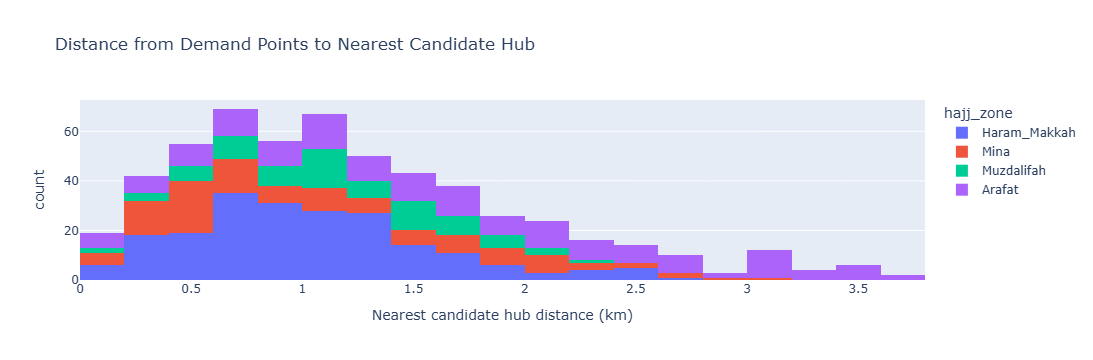

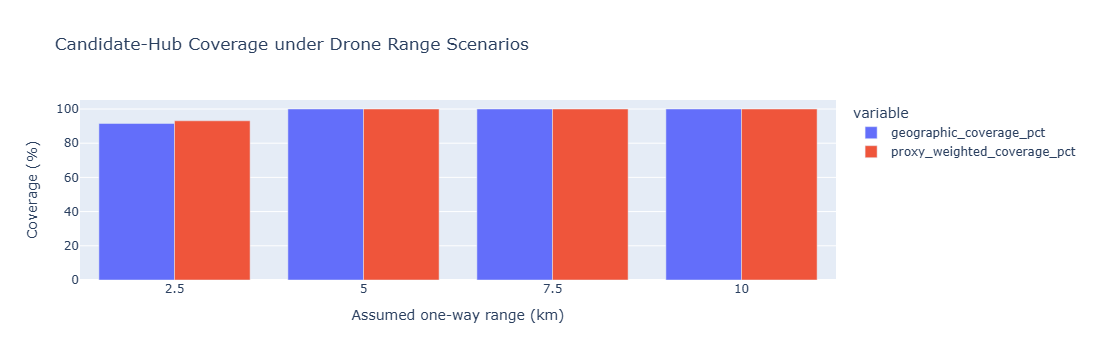

In [ ]:
fig=px.histogram(
    demand,x="nearest_candidate_hub_km",color="hajj_zone",
    nbins=30,title="Distance from Demand Points to Nearest Candidate Hub",
    labels={"nearest_candidate_hub_km":"Nearest candidate hub distance (km)"}
)
fig.show()

fig=px.bar(
    coverage_summary,x="range_km",
    y=["geographic_coverage_pct","proxy_weighted_coverage_pct"],
    barmode="group",
    title="Candidate-Hub Coverage under Drone Range Scenarios",
    labels={"range_km":"Assumed one-way range (km)","value":"Coverage (%)"}
)
fig.show()

## 10. Export candidate hubs, matrices, and coverage results

In [ ]:
hub_gpkg=PROCESSED_DIR/"candidate_drone_hubs_v1.gpkg"
hub_csv=MODEL_DIR/"candidate_drone_hubs_v1.csv"
distance_csv=MODEL_DIR/"demand_to_candidate_hub_air_distance_km_v1.csv"

hubs.to_file(hub_gpkg,layer="candidate_hubs",driver="GPKG")
hubs.drop(columns="geometry").to_csv(hub_csv,index=False,encoding="utf-8-sig")
distance_matrix.to_csv(distance_csv)

for r,C in coverage_matrices.items():
    pd.DataFrame(C,index=demand.demand_point_id,columns=hubs.hub_id).to_csv(
        MODEL_DIR/f"demand_to_hub_coverage_{str(r).replace('.','p')}km_v1.csv"
    )

coverage_summary.to_csv(
    REPORT_DIR/"candidate_hub_range_coverage_summary_v1.csv",
    index=False,encoding="utf-8-sig"
)

demand.drop(columns="geometry").to_csv(
    MODEL_DIR/"baseline_500m_demand_points_with_nearest_hub_v1.csv",
    index=False,encoding="utf-8-sig"
)

print("Candidate hubs:",hub_csv)
print("Distance matrix:",distance_csv)
print("Coverage summary:",REPORT_DIR/"candidate_hub_range_coverage_summary_v1.csv")

Candidate hubs: hajj_drone_project\data\model\candidate_drone_hubs_v1.csv
Distance matrix: hajj_drone_project\data\model\demand_to_candidate_hub_air_distance_km_v1.csv
Coverage summary: hajj_drone_project\outputs\reports\candidate_hub_range_coverage_summary_v1.csv
